# Práctica 9: Minería de Datos - Text Analysis (Word Cloud)
Para esta practica se utilizo una investigacion profunda sobre la busqueda "Salud mental durante pandemia"justamente para realizar un análisis del impacto de COVID-19 en la salud mental, esto debido a que en el dataset utilizado hay carencia de lenguaje natural, solo contiene valores numéricos y categorías cortas y estáticas, como "Received Counseling", "By Sex", "Female" o nombres de estados y grupos de edad.

El procesamiento de lenguaje natural (NLP) requiere limpiar los datos no estructurados antes de analizarlos. Para evitar ambigüedades y ruido en nuestra Minería de Texto, aplicaremos:
1.  Convertir todo el texto a minúsculas y eliminar caracteres especiales, números y signos de puntuación.
2.  Removeremos palabras vacías del idioma español que no aportan valor semántico al análisis de temas.
3.  Separación del corpus de texto en palabras individuales para su conteo.

In [6]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords', quiet=True)
sns.set_theme(style="whitegrid")

# EXTRACCIÓN Y PREPROCESAMIENTO ")

# 1. Extracción de Texto
ruta_archivo = "investigacion_profunda.txt"
with open(ruta_archivo, 'r', encoding='utf-8') as file:
    texto_crudo = file.read()

# 2. Normalización
texto_limpio = texto_crudo.lower()
texto_limpio = re.sub(r'[^\w\s]', '', texto_limpio) # Elimina puntuación
texto_limpio = re.sub(r'\d+', '', texto_limpio)     # Elimina números

# 3. Eliminación de Stop Words
stop_words_es = set(stopwords.words('spanish'))
# Añadimos algunas stopwords extra que suelen colarse en textos académicos
stop_words_es.update(['ciento', 'cada', 'así', 'solo', 'si', 'sino'])

palabras = texto_limpio.split()
palabras_filtradas = [palabra for palabra in palabras if palabra not in stop_words_es]

# texto limpio para la nube de palabras
texto_procesado = ' '.join(palabras_filtradas)

print(f"Total de palabras originales: {len(palabras)}")
print(f"Total de palabras tras limpieza (Tokens útiles): {len(palabras_filtradas)}")

Total de palabras originales: 2485
Total de palabras tras limpieza (Tokens útiles): 1367


C:\Users\THEHE\AppData\Local\Temp\ipykernel_11624\1269665396.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(frecuencias_top), y=list(palabras_top), palette="viridis")


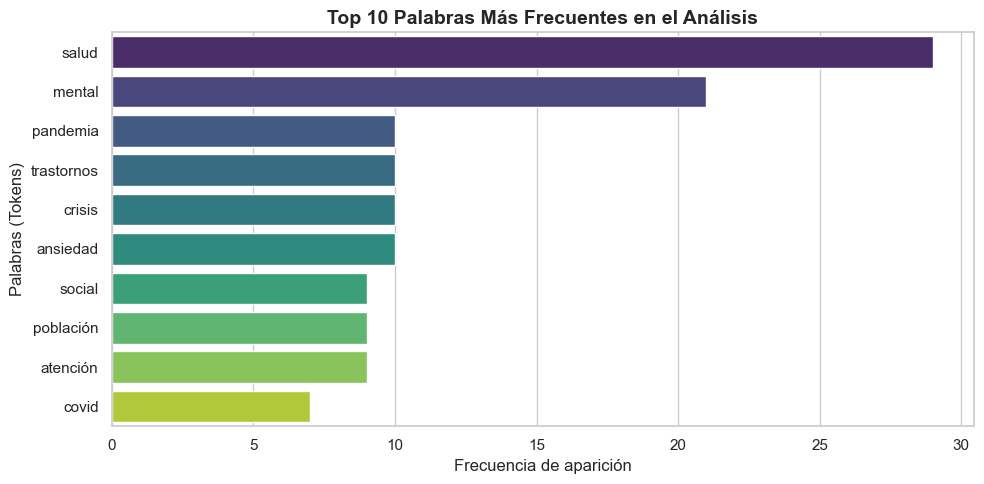

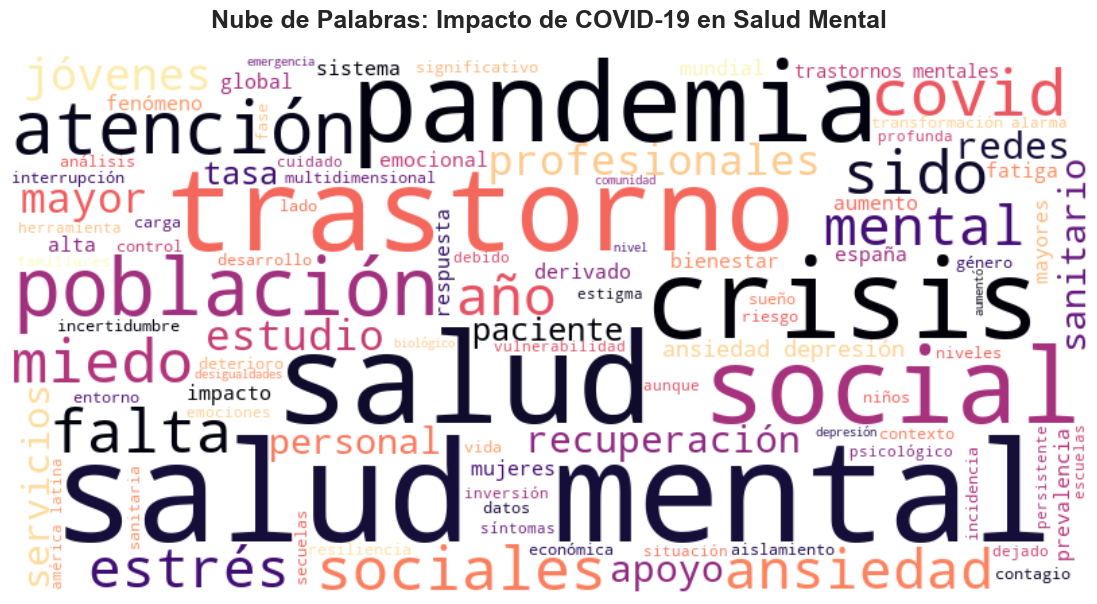

In [7]:
conteo_palabras = Counter(palabras_filtradas)
top_10 = conteo_palabras.most_common(10)

palabras_top, frecuencias_top = zip(*top_10)

# Gráfico de Barras del Top 10
plt.figure(figsize=(10, 5))
sns.barplot(x=list(frecuencias_top), y=list(palabras_top), palette="viridis")
plt.title("Top 10 Palabras Más Frecuentes en el Análisis", fontsize=14, fontweight='bold')
plt.xlabel("Frecuencia de aparición")
plt.ylabel("Palabras (Tokens)")
plt.tight_layout()
plt.show()

# 2. Generación de la Nube de Palabras (Word Cloud)
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='magma',
    max_words=100,
    contour_width=3,
    contour_color='steelblue'
).generate(texto_procesado)

# Dibujar la nube
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Ocultar los ejes
plt.title("Nube de Palabras: Impacto de COVID-19 en Salud Mental", fontsize=18, fontweight='bold', pad=20)
plt.show()